# POMDP agent simplified model — integrated v3 clean

Runs CUDA `traincuda`, original CPU `train(use_gpu=False)`, original CuPy `train(use_gpu=True)`, then policy evaluation histories for all three.

The package applies the non-layered `hist.plot()` fix internally; no notebook metadata patch cells are required.

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd

PATCH_ROOT = os.environ.get(
    "P_TRAINCUDA_ROOT",
    "/home/jlpfritas/HPC-POMDP/v1train_cuda/package_P_traincuda_integrated_v3_clean",
)
PATCH_PY = os.path.join(PATCH_ROOT, "python")
if PATCH_PY not in sys.path:
    sys.path.insert(0, PATCH_PY)

# Avoid old cached v1/v2 modules if the kernel was reused.
for name in list(sys.modules):
    if name.startswith("olfnav_cuda_notebook") or name.startswith("olfnav_cuda_backend"):
        del sys.modules[name]

from olfactory_navigation import Environment
from olfactory_navigation.agents import FSVI_Agent
from olfactory_navigation.agents.model_based_util.environment_converter import minimal_converter

import olfnav_cuda_notebook as ocn
from olfnav_cuda_notebook import (
    enable_cuda_backend,
    clean_start_points,
    run_policy_evaluation,
    run_policy_full_evaluation,
    show_cuda_training_report,
)

CUDA_LIB = os.path.join(PATCH_ROOT, "build", "libpomdp_backup_cuda.so")
print("Using patch module from:", ocn.__file__)
print("CUDA_LIB:", CUDA_LIB)
print("CUDA_LIB exists:", os.path.exists(CUDA_LIB))
assert "integrated_v3_clean" in ocn.__file__ or "package_P_traincuda_integrated_v3_1_clean" in ocn.__file__

Using patch module from: /home/jlpfritas/HPC-POMDP/v1train_cuda/package_P_traincuda_integrated_v3_clean/python/olfnav_cuda_notebook/__init__.py
CUDA_LIB: /home/jlpfritas/HPC-POMDP/v1train_cuda/package_P_traincuda_integrated_v3_clean/build/libpomdp_backup_cuda.so
CUDA_LIB exists: True


In [2]:
PATCH_ROOT = "/home/jlpfritas/HPC-POMDP/v1train_cuda/package_P_traincuda_integrated_v3_clean"
PATCH_PY = os.path.join(PATCH_ROOT, "python")

if PATCH_PY not in sys.path:
    sys.path.insert(0, PATCH_PY)

for name in list(sys.modules):
    if name.startswith("olfnav_cuda_notebook") or name.startswith("olfnav_cuda_backend"):
        del sys.modules[name]

## Configuration

In [3]:
ENV_PATH = (
    "/home/jlpfritas/HPC-POMDP/v3/recon/"
    "Env-olfnav-trim552-fliplr-cropx780-thr1e4/"
    "Env-320_485-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_163_406_radius2"
)

PARTITIONS_TEST = (12, 12)
EXPANSIONS = 1024
GAMMA = 0.95
SEED = 123
CUDA_DEVICE = 0
CUDA_VERSION = "auto"

RUN_CUDA_TRAIN = True
RUN_CPU_TRAIN = True
RUN_CUPY_TRAIN = True
RUN_FULL_EVAL = True
N_EVAL = 100
HORIZON = 1000

OUT_ROOT = Path("tmp") / f"integrated_v3_clean_p{PARTITIONS_TEST[0]}x{PARTITIONS_TEST[1]}_e{EXPANSIONS}"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_ROOT

PosixPath('tmp/integrated_v3_clean_p12x12_e1024')

## Agent factory

[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/Env-olfnav-trim552-fliplr-cropx780-thr1e4/Env-320_485-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_163_406_radius2
[MAKE_AGENT] partitions=(12, 12)
[MAKE_AGENT] seed=123
[MAKE_AGENT] gamma=0.95
[preview] env shape: [320, 485]
[preview] env dimensions: 2
[preview] layer labels: None
[preview] source position: [163 406]
[preview] start_probabilities shape: (320, 485)


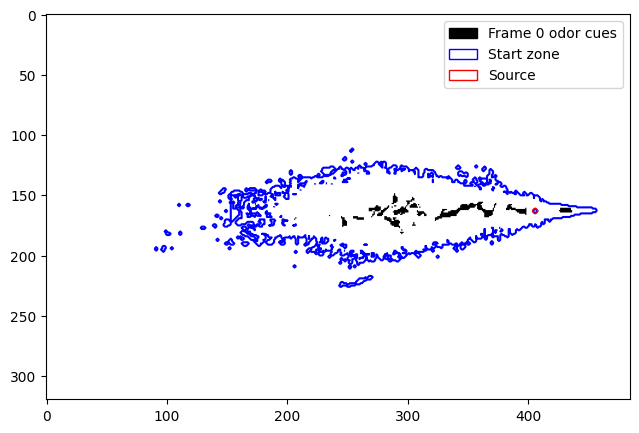

In [4]:
def make_agent(partitions=PARTITIONS_TEST, seed=SEED, gamma=GAMMA, env_path=ENV_PATH, margin_partitions=True):
    print(f"[MAKE_AGENT] env_path={env_path}")
    print(f"[MAKE_AGENT] partitions={partitions}")
    print(f"[MAKE_AGENT] seed={seed}")
    print(f"[MAKE_AGENT] gamma={gamma}")

    env = Environment.load(env_path)
    ocn.normalize_non_layered_environment(env)  # package-level safe metadata normalization

    ag = FSVI_Agent(
        env,
        environment_converter=minimal_converter,
        partitions=list(partitions),
        margin_partitions=margin_partitions,
        seed=seed,
    )
    ag.gamma = gamma
    try:
        ag.model.gamma = gamma
    except Exception:
        pass
    return ag

def describe_agent(agent, name="agent"):
    env = agent.environment
    print(f"[{name}] env shape:", getattr(env, "shape", None))
    print(f"[{name}] env dimensions:", getattr(env, "dimensions", None))
    print(f"[{name}] layer labels:", getattr(env, "environment_layer_labels", getattr(env, "layer_labels", None)))
    print(f"[{name}] source position:", getattr(env, "source_position", None))
    print(f"[{name}] start_probabilities shape:", np.asarray(env.start_probabilities).shape)

ag_preview = make_agent()
describe_agent(ag_preview, "preview")
try:
    ag_preview.environment.plot()
except Exception as e:
    print("Environment plot skipped:", type(e).__name__, e)

## Common training kwargs

In [5]:
COMMON_TRAIN_KWARGS = dict(
    expansions=EXPANSIONS,
    max_belief_growth=10,
    prune_level=1,
    prune_interval=10,
    gamma=GAMMA,
    print_progress=True,
    print_stats=True,
    history_tracking_level=1,
)
COMMON_TRAIN_KWARGS

{'expansions': 1024,
 'max_belief_growth': 10,
 'prune_level': 1,
 'prune_interval': 10,
 'gamma': 0.95,
 'print_progress': True,
 'print_stats': True,
 'history_tracking_level': 1}

## CUDA traincuda

In [6]:
ag_cuda = None
res_cuda = None

if RUN_CUDA_TRAIN:
    if not os.path.exists(CUDA_LIB):
        raise FileNotFoundError(f"Missing CUDA_LIB={CUDA_LIB}. Build with: bash scripts/31_build_backend_lib.sh --arch native --clean")
    ag_cuda_base = make_agent()
    ag_cuda = enable_cuda_backend(
        ag_cuda_base,
        device=CUDA_DEVICE,
        version=CUDA_VERSION,
        gamma=GAMMA,
        lib_path=CUDA_LIB,
    )
    print("traincuda available:", hasattr(ag_cuda, "traincuda"))
    print("CUDA config:", ag_cuda._cuda_backend_config)
    res_cuda = ag_cuda.traincuda(
        **COMMON_TRAIN_KWARGS,
        use_gpu=True,
        outdir=str(OUT_ROOT / "cuda_traincuda"),
        checkpoint_every=25,
        visual=True,
        display_rows=10,
    )
else:
    print("CUDA training skipped")

[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/Env-olfnav-trim552-fliplr-cropx780-thr1e4/Env-320_485-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_163_406_radius2
[MAKE_AGENT] partitions=(12, 12)
[MAKE_AGENT] seed=123
[MAKE_AGENT] gamma=0.95
traincuda available: True
CUDA config: {'lib_path': '/home/jlpfritas/HPC-POMDP/v1train_cuda/package_P_traincuda_integrated_v3_clean/build/libpomdp_backup_cuda.so', 'device': 0, 'version': 'auto', 'gamma': 0.95, 'max_belief_growth': 10, 'prune_interval': 10, 'prune_level': 1, 'compact_cuda_backup_before_append': True, 'cuda_backup_compact_prune_level': 1, 'mdp_use_gpu': False}
CUDA traincuda summary:
{
  "compact_cuda_backup_before_append": true,
  "completed": true,
  "completed_expansions": 1024,
  "cuda_device_visible": "0",
  "cuda_lib_path": "/home/jlpfritas/HPC-POMDP/v1train_cuda/package_P_traincuda_integrated_v3_clean/build/libpomdp_backup_cuda.so",
  "cuda_version_requested": "auto",
  "gamma": 0.95,
  "last_alpha_a

,iter,nB,nG_in,expand_ms,backup_ms,backup_wall_ms,update_ms,iter_total_ms,actual_version,alpha_after,belief_total_after,value_mean_on_union,value_max_on_union,value_min_on_union,pruned,alpha_before_prune,alpha_after_prune,cuda_bkp_rows_raw,cuda_bkp_rows_compact,cuda_backup_compacted
1014,1015,10,6317,0.393867,2.649130,2.713507,12.272977,29.101057,v8_precompute,6324,923,0.124568,20.0,0.016496,False,6324,6324,10,9,True
1015,1016,10,6324,0.402099,2.644043,2.705547,12.230610,28.810504,v8_precompute,6333,923,0.124581,20.0,0.016496,False,6333,6333,10,10,False
1016,1017,10,6333,0.392041,2.654628,2.717903,12.219992,28.799728,v8_precompute,6340,923,0.124582,20.0,0.016496,False,6340,6340,10,7,True
1017,1018,10,6340,0.393729,2.644690,2.707399,69.372139,86.587078,v8_precompute,6348,923,0.124582,20.0,0.016496,False,6348,6348,10,8,True
1018,1019,10,6348,0.422414,2.887256,2.966332,13.201055,30.666144,v8_precompute,6355,923,0.124582,20.0,0.016496,False,6355,6355,10,9,True
1019,1020,10,6355,0.404161,2.806703,2.876366,12.994818,30.216563,v8_precompute,6360,923,0.124582,20.0,0.016496,False,6360,6360,10,7,True
1020,1021,10,6360,0.401768,2.716887,2.784284,11.982798,29.022815,v8_precompute,6365,923,0.124583,20.0,0.016496,True,6365,6365,10,7,True
1021,1022,10,6365,0.403226,2.694853,2.762197,12.322690,29.577025,v8_precompute,6371,923,0.124583,20.0,0.016496,False,6371,6371,10,7,True
1022,1023,10,6371,0.392292,2.673570,2.737699,12.485951,29.559998,v8_precompute,6379,923,0.124583,20.0,0.016496,False,6379,6379,10,8,True
1023,1024,10,6379,0.394171,2.716715,2.782492,12.739549,29.912090,v8_precompute,6386,923,0.124583,20.0,0.016496,False,6386,6386,10,9,True


## Original CPU/native train

In [7]:
ag_cpu = None
hist_cpu_train = None
if RUN_CPU_TRAIN:
    ag_cpu = make_agent()
    hist_cpu_train = ag_cpu.train(**COMMON_TRAIN_KWARGS, use_gpu=False, overwrite_training=True)
    print(hist_cpu_train.summary)
else:
    print("CPU training skipped")

[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/Env-olfnav-trim552-fliplr-cropx780-thr1e4/Env-320_485-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_163_406_radius2
[MAKE_AGENT] partitions=(12, 12)
[MAKE_AGENT] seed=123
[MAKE_AGENT] gamma=0.95
[05/12/2026, 11:37:54] MDP_policy, not provided. Solving MDP with Value Iteration...


  0%|          | 0/1000 [00:00<?, ?it/s]

Summary of Value Iteration run
  - Model: 197-state, 4-action
  - Converged in 212 iterations and 0.0052 seconds
  - Took on average 0.0000s per iteration


Expansions:   0%|          | 0/1024 [00:00<?, ?it/s]

Converged!
Summary of Point Based Value Iteration run
  - Model: 197 state, 4 action, 3 observations
  - Converged or stopped after 293 expansion steps and 293 backup steps.
  - Resulting value function has 1321 alpha vectors.
  - Converged in 10.3035s

  - Expand function took on average 0.0005s and yielded on average 236.88 beliefs per iteration. (0.0000s/it/belief)
  - Backup function took on average 0.0347s and yielded on average 4.51 alpha vectors per iteration. (0.0001s/it/alpha)
  - Pruning function took on average 0.0000s and yielded on average prunings of 0.00 alpha vectors per iteration.
Summary of Point Based Value Iteration run
  - Model: 197 state, 4 action, 3 observations
  - Converged or stopped after 293 expansion steps and 293 backup steps.
  - Resulting value function has 1321 alpha vectors.
  - Converged in 10.3035s

  - Expand function took on average 0.0005s and yielded on average 236.88 beliefs per iteration. (0.0000s/it/belief)
  - Backup function took on average

## Original CuPy/native GPU train

In [8]:
ag_cupy = None
hist_cupy_train = None
if RUN_CUPY_TRAIN:
    import cupy as cp
    cp.cuda.Device(CUDA_DEVICE).use()
    # cp.get_default_memory_pool().free_all_blocks()
    # cp.get_default_pinned_memory_pool().free_all_blocks()
    ag_cupy = make_agent()
    hist_cupy_train = ag_cupy.train(**COMMON_TRAIN_KWARGS, use_gpu=True, overwrite_training=True)
    print(hist_cupy_train.summary)
else:
    print("CuPy training skipped")

[MAKE_AGENT] env_path=/home/jlpfritas/HPC-POMDP/v3/recon/Env-olfnav-trim552-fliplr-cropx780-thr1e4/Env-320_485-marg_20_20_20_20-edge_wrap_vertical-start_odor_present-source_163_406_radius2
[MAKE_AGENT] partitions=(12, 12)
[MAKE_AGENT] seed=123
[MAKE_AGENT] gamma=0.95
[05/12/2026, 11:38:36] MDP_policy, not provided. Solving MDP with Value Iteration...
[05/12/2026, 11:38:36] Sending Model to GPU...
[05/12/2026, 11:38:36]     > Done in 0.008s


  0%|          | 0/1000 [00:00<?, ?it/s]

Summary of Value Iteration run
  - Model: 197-state, 4-action
  - Converged in 212 iterations and 0.2250 seconds
  - Took on average 0.0011s per iteration


Expansions:   0%|          | 0/1024 [00:00<?, ?it/s]

Converged!
Summary of Point Based Value Iteration run
  - Model: 197 state, 4 action, 3 observations
  - Converged or stopped after 253 expansion steps and 253 backup steps.
  - Resulting value function has 1056 alpha vectors.
  - Converged in 2.5855s

  - Expand function took on average 0.0087s and yielded on average 225.02 beliefs per iteration. (0.0001s/it/belief)
  - Backup function took on average 0.0015s and yielded on average 4.17 alpha vectors per iteration. (0.0000s/it/alpha)
  - Pruning function took on average 0.0000s and yielded on average prunings of 0.00 alpha vectors per iteration.
Summary of Point Based Value Iteration run
  - Model: 197 state, 4 action, 3 observations
  - Converged or stopped after 253 expansion steps and 253 backup steps.
  - Resulting value function has 1056 alpha vectors.
  - Converged in 2.5855s

  - Expand function took on average 0.0087s and yielded on average 225.02 beliefs per iteration. (0.0001s/it/belief)
  - Backup function took on average 0

In [12]:
hist_cupy_train = ag_cupy.train(**COMMON_TRAIN_KWARGS, use_gpu=True, overwrite_training=True)

[05/05/2026, 13:00:34] MDP_policy, not provided. Solving MDP with Value Iteration...


  0%|          | 0/1000 [00:00<?, ?it/s]

Summary of Value Iteration run
  - Model: 197-state, 4-action
  - Converged in 212 iterations and 0.1386 seconds
  - Took on average 0.0007s per iteration
[warning] A GPU instance already existed and is being recreated.
[warning] The value function is being overwritten


Expansions:   0%|          | 0/1024 [00:00<?, ?it/s]

Converged!
Summary of Point Based Value Iteration run
  - Model: 197 state, 4 action, 3 observations
  - Converged or stopped after 308 expansion steps and 308 backup steps.
  - Resulting value function has 1379 alpha vectors.
  - Converged in 2.4518s

  - Expand function took on average 0.0067s and yielded on average 232.26 beliefs per iteration. (0.0000s/it/belief)
  - Backup function took on average 0.0013s and yielded on average 4.47 alpha vectors per iteration. (0.0000s/it/alpha)
  - Pruning function took on average 0.0000s and yielded on average prunings of 0.00 alpha vectors per iteration.


## Training comparison

In [9]:
def safe_len_value_function(agent):
    if agent is None:
        return None
    vf = getattr(agent, "value_function", None)
    if vf is None and hasattr(agent, "native_agent"):
        vf = getattr(agent.native_agent, "value_function", None)
    if vf is None:
        return None
    for fn in (lambda x: len(x), lambda x: len(x.alpha_vectors), lambda x: x.alpha_vector_array.shape[0]):
        try:
            return int(fn(vf))
        except Exception:
            pass
    return None

def safe_len_belief(agent):
    if agent is None:
        return None
    obj = agent.native_agent if hasattr(agent, "native_agent") else agent
    for attr in ("belief_set", "belief", "beliefs"):
        b = getattr(obj, attr, None)
        if b is None:
            continue
        for fn in (lambda x: len(x), lambda x: x.belief_array.shape[0], lambda x: x.array.shape[0]):
            try:
                return int(fn(b))
            except Exception:
                pass
    return None

rows = []
for label, ag, res in [("cuda_traincuda", ag_cuda, res_cuda), ("cpu_native", ag_cpu, None), ("cupy_native_gpu", ag_cupy, None)]:
    if ag is None:
        continue
    rows.append({
        "path": label,
        "partitions": f"{PARTITIONS_TEST[0]}x{PARTITIONS_TEST[1]}",
        "expansions": EXPANSIONS,
        "alpha_final": safe_len_value_function(ag),
        "belief_final": safe_len_belief(ag),
        "wall_s": None if res is None else res.summary.get("total_wall_s"),
        "sum_backup_ms": None if res is None else res.summary.get("sum_backup_ms"),
    })

df_train_compare = pd.DataFrame(rows)
display(df_train_compare)
df_train_compare.to_csv(OUT_ROOT / "training_compare_summary.csv", index=False)
if res_cuda is not None:
    res_cuda.to_dataframe().to_csv(OUT_ROOT / "cuda_traincuda_rows.csv", index=False)

,path,partitions,expansions,alpha_final,belief_final,wall_s,sum_backup_ms
0,cuda_traincuda,12x12,1024,6386,923.0,14.379741,1427.066742
1,cpu_native,12x12,1024,1321,NaN,NaN,NaN
2,cupy_native_gpu,12x12,1024,1056,NaN,NaN,NaN


## Shared clean starts

In [10]:
ref_agent = ag_cuda or ag_cpu or ag_cupy
start_points_clean = clean_start_points(ref_agent)
start_points_eval = start_points_clean if N_EVAL is None else start_points_clean[:int(N_EVAL)]
print("clean start points:", start_points_clean.shape)
print("eval start points:", start_points_eval.shape)
start_points_eval[:5]

clean start points: (13163, 2)
eval start points: (100, 2)


array([[112, 254],
       [113, 253],
       [119, 248],
       [120, 247],
       [120, 248]])

## Policy evaluation histories

In [11]:
COMMON_EVAL_KWARGS = dict(
    horizon=HORIZON,
    reward_discount=GAMMA,
    use_gpu=False,
    time_shift=False,
    time_loop=False,
    print_progress=True,
    print_stats=True,
)

hist_cuda_eval = run_policy_evaluation(ag_cuda, start_points=start_points_eval, n=len(start_points_eval), **COMMON_EVAL_KWARGS) if ag_cuda is not None else None
hist_cpu_eval = run_policy_evaluation(ag_cpu, start_points=start_points_eval, n=len(start_points_eval), **COMMON_EVAL_KWARGS) if ag_cpu is not None else None
hist_cupy_eval = run_policy_evaluation(ag_cupy, start_points=start_points_eval, n=len(start_points_eval), **COMMON_EVAL_KWARGS) if ag_cupy is not None else None

Using the provided environment, not the agent environment.


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 1.865s:
Simulations reached goal: 5/100 (95 failures (reached horizon: 95)) (5.00% success)
 - Average step count:                 988.340 +- 69.78 (Successful only: 766.800 +- 236.53)
 - Extra steps:                        819.270 +- 75.49 (Successful only: 597.600 +- 244.58)
 - Average discounted rewards (ADR):   0.000 +- 0.00 (Successful only: 0.000 +- 0.00)
 - Tmin/T:                             0.173 +- 0.04 (Successful only: 0.246 +- 0.11)
Using the provided environment, not the agent environment.


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 1.351s:
Simulations reached goal: 0/100 (100 failures (reached horizon: 100)) (0.00% success)
Using the provided environment, not the agent environment.


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 1.331s:
Simulations reached goal: 0/100 (100 failures (reached horizon: 100)) (0.00% success)


## Native hist.plot outputs

CUDA policy evaluation plot
CPU/native policy evaluation plot
CuPy/native GPU policy evaluation plot


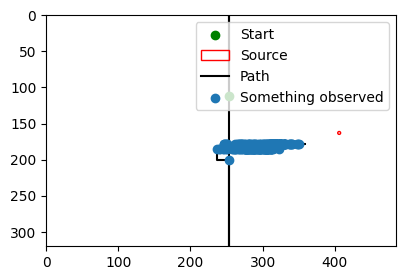

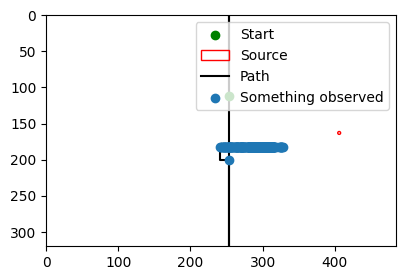

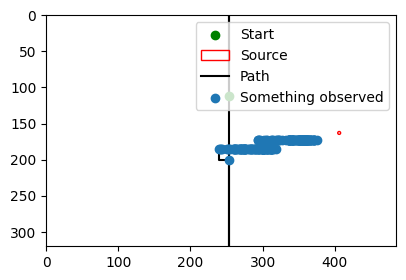

In [12]:
if hist_cuda_eval is not None:
    print("CUDA policy evaluation plot")
    hist_cuda_eval.plot()

if hist_cpu_eval is not None:
    print("CPU/native policy evaluation plot")
    hist_cpu_eval.plot()

if hist_cupy_eval is not None:
    print("CuPy/native GPU policy evaluation plot")
    hist_cupy_eval.plot()

## Optional full evaluation

In [ ]:
hist_cuda_full = hist_cpu_full = hist_cupy_full = None
if RUN_FULL_EVAL:
    hist_cuda_full = run_policy_full_evaluation(ag_cuda, **COMMON_EVAL_KWARGS) if ag_cuda is not None else None
    hist_cpu_full = run_policy_full_evaluation(ag_cpu, **COMMON_EVAL_KWARGS) if ag_cpu is not None else None
    hist_cupy_full = run_policy_full_evaluation(ag_cupy, **COMMON_EVAL_KWARGS) if ag_cupy is not None else None
else:
    print("RUN_FULL_EVAL=False")

Using the provided environment, not the agent environment.


  0%|          | 0/1000 [00:00<?, ?it/s]

Simulations done in 202.923s:
Simulations reached goal: 2564/13163 (10599 failures (reached horizon: 10599)) (19.48% success)
 - Average step count:                 865.932 +- 298.03 (Successful only: 311.723 +- 273.03)
 - Extra steps:                        733.772 +- 293.86 (Successful only: 194.024 +- 253.80)
 - Average discounted rewards (ADR):   0.009 +- 0.07 (Successful only: 0.048 +- 0.15)
 - Tmin/T:                             0.229 +- 0.25 (Successful only: 0.614 +- 0.36)
Using the provided environment, not the agent environment.


  0%|          | 0/1000 [00:00<?, ?it/s]

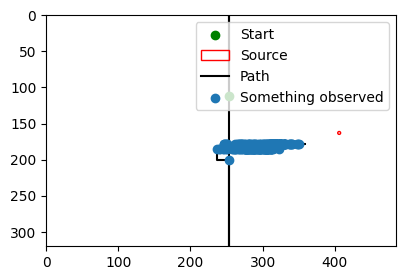

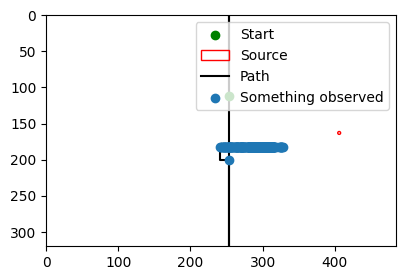

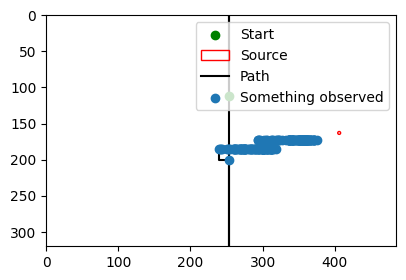

In [ ]:
if hist_cuda_full is not None:
    hist_cuda_full.plot()
if hist_cpu_full is not None:
    hist_cpu_full.plot()
if hist_cupy_full is not None:
    hist_cupy_full.plot()

## Save metadata

In [ ]:
metadata = {
    "patch_root": PATCH_ROOT,
    "cuda_lib": CUDA_LIB,
    "env_path": ENV_PATH,
    "partitions": list(PARTITIONS_TEST),
    "expansions": EXPANSIONS,
    "gamma": GAMMA,
    "n_eval": None if N_EVAL is None else int(N_EVAL),
    "horizon": HORIZON,
    "module_file": ocn.__file__,
}
(OUT_ROOT / "notebook_run_metadata.json").write_text(json.dumps(metadata, indent=2, sort_keys=True) + "")
print("Saved:", OUT_ROOT)

Saved: tmp/integrated_v3_clean_p24x24_e100
